## We need to recreate three mathematical formulae for linear regression

1. Cost Function ( Mean Squared error )
2. Gradient functon
3. Gradient Descent Function

In [7]:
# Necessary Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Get the dataset

In [28]:
data = pd.read_csv("Salary_Data.csv")
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [50]:
x_train = data["YearsExperience"].values
y_train = data["Salary"].values

30
121872.0


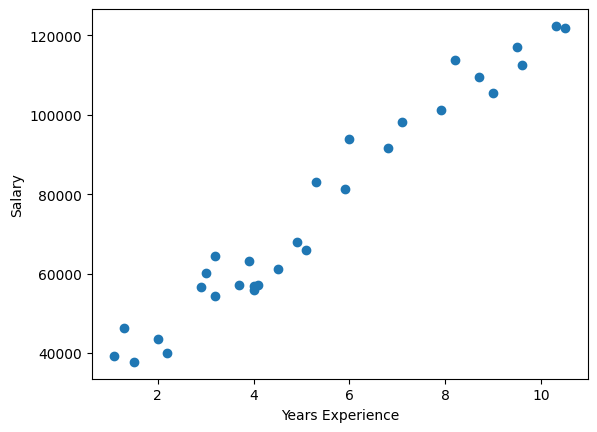

In [14]:
plt.scatter(x_train, y_train)
plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.show()

### Cost Function
Basically the mean of sum of difference between a point and its corresponding point on the line

In [56]:
# w = slope
# x , y coordinates defined as lists to capture all points
# b = y-intercept

def cost_function(x, y, w, b):
    m = len(x) # Total number of points
    sum = 0
    
    for i in range(m):
        f = w * x[i] + b
        sum += (f - y[i]) **2

    total_cost = 1/(2*m) * sum
    return total_cost

    

### Gradient Function

We find the derivate dc(m,c)/dm

In [30]:
def gradient_function(x, y, w, b):
    m = len(x)
    dc_dw = 0 
    dc_db = 0

    for i in range (m):
        f = w*x[i] + b
        dc_dw += x[i] * ( f - y[i] )
        dc_db += ( f - y[i] )

    dc_dw = 1/m * dc_dw
    dc_db = 1/m * dc_db

    return dc_dw, dc_db

### Gradient Descent Function

we try to determine the value for w (slope) and b (y-axis value) for when the cost is lowest using the gradient function basically derivative magic.

In [33]:
# alpha = how big steps we take while aproaching the lowest point ( in gradient descent terms )
# iterations = number of cycles we repeat the process

def gradient_descent(x,y, alpha, iterations):
    w = 0
    b = 0 
    
    for i in range(iterations):
        dc_dw, dc_db = gradient_function(x, y, w, b)

        w = w - alpha*dc_dw
        b = b - alpha*dc_db

        print(f"Iteration {i}: Cost = {cost_function(x, y, w, b)}")

    return w,b

In [ ]:
alpha = 0.01
iterations = 10000

optimal_w, optimal_b = gradient_descent(x_train, y_train, alpha, iterations) 

print(f"w: {optimal_w:.4f}, b: {optimal_b:.4f}")


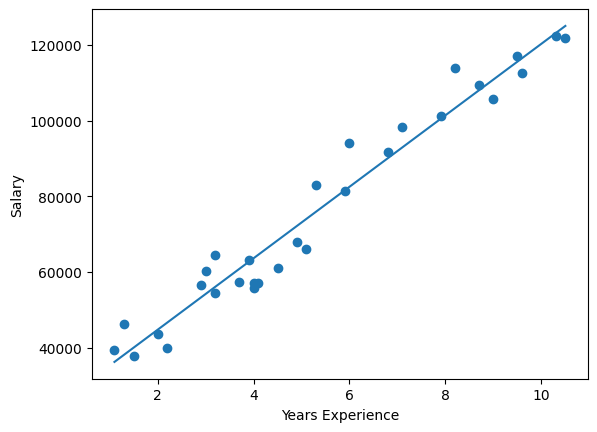

In [59]:
plt.scatter(x_train, y_train)
plt.xlabel("Years Experience")
plt.ylabel("Salary")

x_line = np.array(x_train)
y_line = optimal_w * x_line + optimal_b                 # y = wx + b

plt.plot(x_line, y_line) 

plt.show()